<a href="https://colab.research.google.com/github/broistg/ML-Assignment-DNAC1/blob/main/notebooks/BTL3_traditional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.&nbsp;User manual

This Google Colab file implements a deep learning pipeline for an image dataset (CIFAR-10). To run this notebook, do the following:
1. First click the Colab `Run all` button. Due to some library conflicts you will need to restart session in the first cell below.
2. After that click `Run all` again (library installation and dataset loading are automated).
3. Select the confiuration you want in the last cell (default: fine tuning DistilBERT model).
4. After that click `Run Pipeline` in the last cell. The pipeline will run according to your configuration.

If you want to rerun the pipeline with another configuration, you need to rerun the last cell and then repeat from step 3.

# 1.&nbsp;Prepare the necessary data and libraries

## 1.1.&nbsp;Verify and install necessary libraries

In [ ]:
# !pip install --quiet timm==0.6.12
!pip install --quiet timm
!pip install --quiet ipywidgets
!pip install --quiet kaleido
!pip install --quiet huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 3.6 MB/s eta 0:00:00


In [ ]:
import os
import time
import math
import random
from pathlib import Path
from collections import Counter
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
from torchvision.datasets import CIFAR10

import timm
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib
from huggingface_hub import hf_hub_download, HfApi


# For widgets
import ipywidgets as widgets
from IPython.display import display, clear_output

# For progress bars
from tqdm.notebook import tqdm

# Utilities
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

# Ensure reproducibility
RND = 42
random.seed(RND); np.random.seed(RND); torch.manual_seed(RND)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RND)

ROOT = Path('.').absolute()
FEATURE_ROOT = ROOT / 'features'
FEATURE_ROOT.mkdir(exist_ok=True)

REPO_ID = 'LeTienDat/BTL3_CIFAR-10'

Device: cpu


## 1.2.&nbsp;Download and store the dataset

In [ ]:
def get_datasets(download_root='data', val_split_ratio=0.1):
    download_root = Path(download_root)
    download_root.mkdir(parents=True, exist_ok=True)

    transform_raw = transforms.Compose([transforms.ToTensor()])
    full_train = CIFAR10(root=str(download_root), train=True, download=True, transform=transform_raw)
    test_set = CIFAR10(root=str(download_root), train=False, download=True, transform=transform_raw)

    # Create stratified validation split from train
    train_indices, val_indices, train_labels, val_labels = train_test_split(
        range(len(full_train)),
        full_train.targets,
        test_size=val_split_ratio,
        stratify=full_train.targets,
        random_state=RND
    )

    train_set = Subset(full_train, train_indices)
    val_set = Subset(full_train, val_indices)

    return train_set, val_set, test_set

train_set, val_set, test_set = get_datasets()
# Add printing image shape and data type
sample_img, _ = train_set[0]
print(f"Image shape: {sample_img.shape}, Image dtype: {sample_img.dtype}")
print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

# helper to get class names
_CIFAR10_CLASSES = train_set.dataset.classes if isinstance(train_set, Subset) else train_set.dataset.classes
print('Classes:', _CIFAR10_CLASSES)

100%|██████████| 170M/170M [00:01<00:00, 87.5MB/s]


Image shape: torch.Size([3, 32, 32]), Image dtype: torch.float32
Train: 45000, Val: 5000, Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# 2.&nbsp;Exploratory Data Analysis (EDA)

--- TRAIN ---


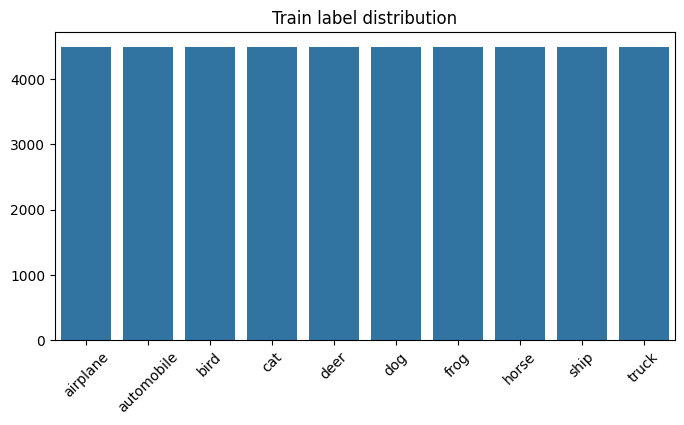

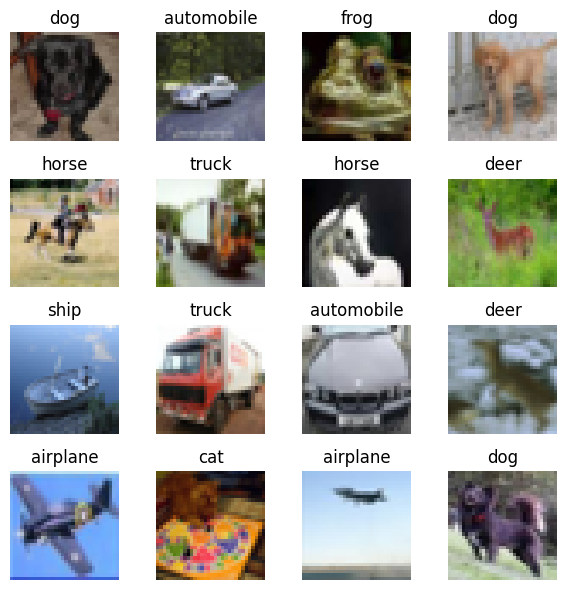

--- VAL ---


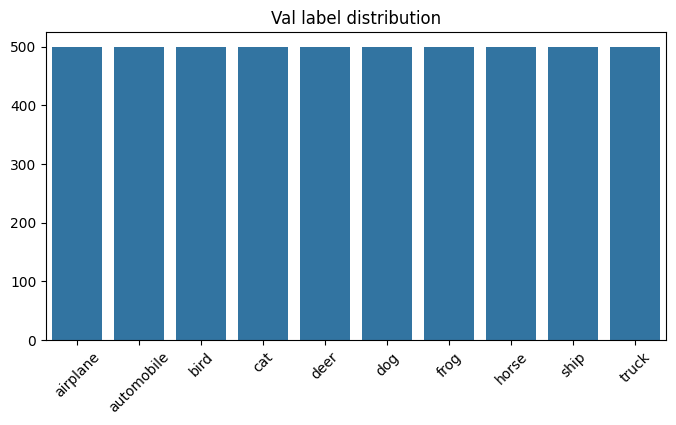

--- TEST ---


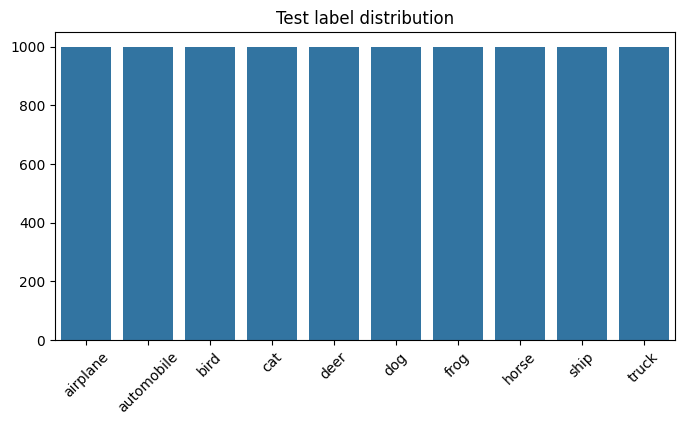

In [ ]:
def show_label_distribution(dataset, title='Label distribution'):
    labels = []
    if isinstance(dataset, Subset):
        for idx in dataset.indices:
            labels.append(dataset.dataset.targets[idx])
    else:
        labels = dataset.targets
    counter = Counter(labels)
    xs = [ _CIFAR10_CLASSES[i] for i in sorted(counter.keys())]
    ys = [ counter[i] for i in sorted(counter.keys())]
    plt.figure(figsize=(8,4))
    sns.barplot(x=xs, y=ys)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()


def show_sample_grid(dataset, n=16, resize=None):
    fig, axes = plt.subplots(int(math.sqrt(n)), int(math.sqrt(n)), figsize=(6,6))
    axes = axes.flatten()
    rng = np.random.default_rng()
    idxs = rng.choice(len(dataset), size=n, replace=False)
    for ax, i in zip(axes, idxs):
        img, label = dataset[i]
        if isinstance(img, torch.Tensor):
            img = transforms.ToPILImage()(img)
        if resize is not None:
            img = img.resize((resize, resize))
        ax.imshow(np.asarray(img))
        ax.set_title(_CIFAR10_CLASSES[label])
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def eda_report(train_set, val_set, test_set):
    print('--- TRAIN ---')
    show_label_distribution(train_set, 'Train label distribution')
    show_sample_grid(train_set, n=16)
    print('--- VAL ---')
    show_label_distribution(val_set, 'Val label distribution')
    print('--- TEST ---')
    show_label_distribution(test_set, 'Test label distribution')

# Run a quick EDA by default
eda_report(train_set, val_set, test_set)

# 3.&nbsp;Data Processing

## 3.1.&nbsp;Image Normalization

In [ ]:
# Default normalization in torchvision models: ImageNet mean/std
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def build_transform(resize=224):
    return transforms.Compose([
        transforms.Resize((resize, resize)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

## 3.2.&nbsp;Feature Extraction

In [ ]:
# Model factory for feature extractors
MODEL_CHOICES = {
    'VGG16': dict(source='torchvision', name='vgg16'),
    'ResNet50': dict(source='torchvision', name='resnet50'),
    'EfficientNet-B0': dict(source='torchvision', name='efficientnet_b0'),
    'ViT': dict(source='timm', name='vit_base_patch16_224'),
    'Swin Transformer': dict(source='timm', name='swin_base_patch4_window7_224')
}

def create_feature_extractor(model_key, device=DEVICE):
    """Return a model that outputs feature vectors (1D per image)
       We'll strip classification heads when possible and avgpool.
    """
    info = MODEL_CHOICES[model_key]
    if info['source'] == 'torchvision':
        if info['name'] == 'vgg16':
            model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1).to(device)
            model.classifier = nn.Identity()
            model.eval()
            # After features: flatten
            def forward_fn(x):
                with torch.no_grad():
                    feat = model(x)
                    feat = torch.flatten(feat, 1)
                return feat
            feat_dim = 25088  # 512 * 7 * 7 for VGG16 with 224 input
            return forward_fn, feat_dim
        elif info['name'] == 'resnet50':
            model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1).to(device)
            # Remove fc
            model.fc = nn.Identity()
            model.eval()
            def forward_fn(x):
                with torch.no_grad():
                    feat = model(x)
                    feat = feat.view(feat.size(0), -1)
                return feat
            feat_dim = 2048
            return forward_fn, feat_dim
        elif info['name'] == 'efficientnet_b0':
            model = torchvision.models.efficientnet_b0(weights=torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1).to(device)
            model.classifier = nn.Identity()
            model.eval()
            def forward_fn(x):
                with torch.no_grad():
                    feat = model(x)
                    feat = torch.flatten(feat, 1)
                return feat
            feat_dim = 1280
            return forward_fn, feat_dim
    else:
        # use timm
        model = timm.create_model(info['name'], pretrained=True, num_classes=0, global_pool='avg').to(device)
        model.eval()
        def forward_fn(x):
            with torch.no_grad():
                feat = model(x)
            return feat
        # try to get feature dim
        feat_dim = model.num_features if hasattr(model, 'num_features') else None
        return forward_fn, feat_dim

## 3.3.&nbsp;Data Preprocessing Pipeline
Features are loaded if saved, otherwise re-extract.

In [ ]:
# Feature extraction pipeline
def dataset_to_dataloader(dataset, transform, batch_size=64, num_workers=2):
    """Wrap dataset with transform and return DataLoader"""
    # Create a copy of dataset that applies transform on the fly
    class _Wrapped(torch.utils.data.Dataset):
        def __init__(self, ds, transform):
            self.ds = ds
            self.transform = transform
        def __len__(self):
            return len(self.ds)
        def __getitem__(self, idx):
            img, label = self.ds[idx]
            if not isinstance(img, Image.Image):
                img = transforms.ToPILImage()(img)
            img = self.transform(img)
            return img, label
    wrapped = _Wrapped(dataset, transform)
    return DataLoader(wrapped, batch_size=batch_size, shuffle=False, num_workers=num_workers)

def file_exists_in_repo(repo_id, path, repo_type="dataset"):
    api = HfApi()
    files = api.list_repo_files(repo_id=repo_id, repo_type=repo_type)
    return path in files

def extract_features_for_split(split_name, dataset, model_key, resize=224, batch_size=64, force_reextract=False, repo_id=None):
    """Extract (or load if exist) features for a split (train/val/test)
       returns X (numpy), y (numpy), feature_path
    """
    feature_dir = FEATURE_ROOT / model_key
    feature_dir.mkdir(parents=True, exist_ok=True)

    feat_file = feature_dir / f'{split_name}_features.npz'
    remote_path = f'{model_key}/{split_name}_features.npz'

    # Check if feature file exists locally or in repo
    if feat_file.exists() and (not force_reextract):
        print(f'Loading cached features: {feat_file}')
        loader = np.load(feat_file)
        return loader['X'], loader['y'], feat_file
    elif repo_id is not None and file_exists_in_repo(repo_id, remote_path, repo_type="dataset"):
        try:
            print(f'Downloading features from repo: {repo_id}/{remote_path}')
            path = hf_hub_download(
                repo_id=repo_id,
                filename=f"{model_key}/{split_name}_features.npz",
                repo_type="dataset",
                local_dir=FEATURE_ROOT,
            )
            print(f'Downloaded features to: {path}')
            loader = np.load(path)
            return loader['X'], loader['y'], feat_file
        except Exception as e:
            print(f"Could not download features from repo: {e}")
            print("Proceeding with feature extraction...")

    # else extract
    print('Creating transform...')
    transform = build_transform(resize)
    dl = dataset_to_dataloader(dataset, transform, batch_size=batch_size)
    forward_fn, feat_dim = create_feature_extractor(model_key)
    if feat_dim is None:
        # we will infer dynamically
        pass

    Xs = []
    Ys = []
    start = time.time()
    print(f'Extracting features for {split_name}...')
    for imgs, labels in tqdm(dl, desc=f'Extracting {split_name} features'):
        imgs = imgs.to(DEVICE)
        feats = forward_fn(imgs)
        feats = feats.detach().cpu().numpy()
        Xs.append(feats)
        Ys.append(np.array(labels))
    X = np.vstack(Xs)
    y = np.concatenate(Ys)
    duration = time.time() - start
    print(f'Extracted features for {split_name} shape={X.shape} in {duration:.1f}s')

    np.savez_compressed(feat_file, X=X, y=y)
    return X, y, feat_file

## 3.4.&nbsp;Post-processing
Scaler and PCA

In [ ]:
def fit_scaler_and_pca(X_train, use_pca=True, pca_dim=256):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_train)
    pca = None
    if use_pca:
        pca = PCA(n_components=min(pca_dim, Xs.shape[1]))
        Xs = pca.fit_transform(Xs)
    return scaler, pca, Xs

def transform_with_scaler_pca(X, scaler, pca=None):
    Xs = scaler.transform(X)
    if pca is not None:
        Xs = pca.transform(Xs)
    return Xs

# 4.&nbsp;Training and Evaluation

In [ ]:
CLASSIFIERS = {
    'LogisticRegression': LogisticRegression,
    'SVM': SVC,
    'RandomForest': RandomForestClassifier,
    'k-NN': KNeighborsClassifier,
    'ShallowMLP': MLPClassifier
}

def create_classifier(name, **kwargs):
    if name == 'LogisticRegression':
        return LogisticRegression(penalty='l2', solver='saga', max_iter=2000, **kwargs)
    if name == 'SVM':
        return SVC(probability=True, **kwargs)
    if name == 'RandomForest':
        return RandomForestClassifier(**kwargs)
    if name == 'k-NN':
        return KNeighborsClassifier(**kwargs)
    if name == 'ShallowMLP':
        return MLPClassifier(hidden_layer_sizes=(512,), max_iter=500, **kwargs)
    raise ValueError('Unknown classifier')

# train + evaluate wrapper
def train_and_evaluate(X_train, y_train, X_val, y_val, X_test, y_test, clf_name, clf_kwargs):
    clf = create_classifier(clf_name, **clf_kwargs)
    print(f'Training {clf_name}...')
    t0 = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - t0
    print(f'Training finished in {train_time:.2f}s.')

    print(f'Evaluating {clf_name}...')
    t0 = time.time()
    preds = clf.predict(X_test)
    predict_time = time.time() - t0
    print(f'Evaluation finished in {predict_time:.4f}s.')

    acc = accuracy_score(y_test, preds)
    rep = classification_report(y_test, preds, target_names=_CIFAR10_CLASSES, digits=4)
    cm = confusion_matrix(y_test, preds)
    return dict(clf=clf, acc=acc, report=rep, cm=cm, train_time=train_time, predict_time=predict_time, preds=preds)

# 5.&nbsp;Visualization

In [ ]:
def plot_confusion_matrix(cm, labels=_CIFAR10_CLASSES, figsize=(10,8)):
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# 5.&nbsp;Combined Pipeline

In [ ]:
def run_pipeline(config):
    """config: dict with keys:
       - resize
       - model_name
       - repo_path
       - pca (bool), pca_dim
       - classifier_name, classifier_kwargs
    """
    print('Running pipeline with config:', config)

    model_key = config['model_name']
    resize = config['resize']
    # extract/load features
    X_train, y_train, ftrain = extract_features_for_split('train', train_set, model_key, resize, batch_size=128, repo_id=REPO_ID)
    X_val, y_val, fval = extract_features_for_split('val', val_set, model_key, resize, batch_size=128, repo_id=REPO_ID)
    X_test, y_test, ftest = extract_features_for_split('test', test_set, model_key, resize, batch_size=128, repo_id=REPO_ID)

    # Postprocess
    use_pca = config['pca']
    pca_dim = config['pca_dim']
    scaler, pca, X_train_proc = fit_scaler_and_pca(X_train, use_pca, pca_dim)
    X_val_proc = transform_with_scaler_pca(X_val, scaler, pca)
    X_test_proc = transform_with_scaler_pca(X_test, scaler, pca)

    # Train classifier
    clf_name = config['classifier_name']
    clf_kwargs = config.get('classifier_kwargs', {})
    results = train_and_evaluate(X_train_proc, y_train, X_val_proc, y_val, X_test_proc, y_test, clf_name, clf_kwargs)

    return results

# 6.&nbsp;Comparison Pipeline

In [ ]:
# Comparison preset selections
compare_models = ['ResNet50','EfficientNet-B0','ViT']
compare_classifiers = ['LogisticRegression','SVM']

def run_comparison():
    results = []
    for m, c in product(compare_models, compare_classifiers):
        cfg = dict(resize=224, model_key=m, pca=True, pca_dim=256, classifier_name=c, classifier_kwargs={})
        try:
            r = run_pipeline(cfg)
            results.append((m, c, r['acc'], r['predict_time']))
        except Exception as e:
            print(f"Failed {m}-{c}: {e}")
    df = pd.DataFrame(results, columns=['Feature Model','Classifier','Accuracy','Inference Time'])
    print(df)
    best = df.loc[df['Accuracy'].idxmax()]
    print("Top model:", best)
    plt.figure(figsize=(8,4)); sns.barplot(data=df, x='Feature Model', y='Accuracy', hue='Classifier'); plt.show()
    plt.figure(figsize=(6,5)); plt.scatter(df['Inference Time'], df['Accuracy']); plt.xlabel('Inference Time'); plt.ylabel('Accuracy'); plt.show()

# 7.&nbsp;Build Config UI

In [ ]:
# Controls
mode_widget = widgets.ToggleButtons(options=['Single Model', 'Comparison'], value='Single Model', description='Mode')
resize_widget = widgets.IntSlider(value=224, min=32, max=512, step=8, description='Resize')
model_widget = widgets.Dropdown(options=(MODEL_CHOICES.keys()), value='ResNet50', description='Extractor')

pca_widget = widgets.Checkbox(value=True, description='Use PCA')
pca_dim_widget = widgets.IntSlider(value=256, min=16, max=2048, step=16, description='PCA dim')

classifier_widget = widgets.Dropdown(options=list(CLASSIFIERS.keys()), value='LogisticRegression', description='Classifier')

# classifier specific widgets
# LogisticRegression: C
log_C = widgets.FloatLogSlider(value=1.0, base=10, min=-4, max=2, step=0.1, description='LogReg C')
# SVM: C, gamma
svm_C = widgets.FloatLogSlider(value=1.0, base=10, min=-4, max=2, step=0.1, description='SVM C')
svm_gamma = widgets.Dropdown(options=['scale','auto'], value='scale', description='gamma')
# RandomForest: n_estimators, max_depth
rf_n = widgets.IntSlider(value=100, min=10, max=1000, step=10, description='n_trees')
rf_depth = widgets.IntSlider(value=20, min=1, max=100, step=1, description='max_depth')
# kNN: n_neighbors
knn_k = widgets.IntSlider(value=5, min=1, max=50, step=1, description='k')
# MLP: hidden_size, alpha
mlp_hidden = widgets.IntSlider(value=512, min=32, max=2048, step=32, description='hidden_size')
mlp_alpha = widgets.FloatLogSlider(value=0.0001, base=10, min=-6, max=-1, step=0.1, description='alpha')

run_button = widgets.Button(description='Run pipeline', button_style='success')
run_compare_button = widgets.Button(description='Run comparison', button_style='warning')
output = widgets.Output()

# dynamic visibility
param_box = widgets.VBox([])

def update_param_box(change=None):
    name = classifier_widget.value
    if name == 'LogisticRegression':
        param_box.children = [log_C]
    elif name == 'SVM':
        param_box.children = [svm_C, svm_gamma]
    elif name == 'RandomForest':
        param_box.children = [rf_n, rf_depth]
    elif name == 'k-NN':
        param_box.children = [knn_k]
    elif name == 'ShallowMLP':
        param_box.children = [mlp_hidden, mlp_alpha]

classifier_widget.observe(update_param_box, names='value')
update_param_box()

# PCA dim visibility
def update_pca_dim_visible(change=None):
    pca_dim_widget.layout.display = '' if pca_widget.value else 'none'

pca_widget.observe(update_pca_dim_visible, names='value')
update_pca_dim_visible()

# Mode change config box
config_box = widgets.VBox([])
def update_config_box(change=None):
    if mode_widget.value == 'Single Model':
        config_box.children = [resize_widget, model_widget, pca_widget, pca_dim_widget, classifier_widget, param_box, run_button]
    elif mode_widget.value == 'Comparison':
        config_box.children = [run_compare_button]

mode_widget.observe(update_config_box, names='value')
update_config_box()

# Run button handler
def on_run_clicked(b):
    with output:
        output.clear_output(wait=True)
        cfg = {
            'resize': resize_widget.value,
            'model_name': model_widget.value,
            'pca': pca_widget.value,
            'pca_dim': pca_dim_widget.value,
            'classifier_name': classifier_widget.value,
            'classifier_kwargs': {}
        }
        # populate classifier kwargs
        if cfg['classifier_name'] == 'LogisticRegression':
            cfg['classifier_kwargs'] = {'C': float(log_C.value), 'n_jobs': -1}
        elif cfg['classifier_name'] == 'SVM':
            cfg['classifier_kwargs'] = {'C': float(svm_C.value), 'gamma': svm_gamma.value}
        elif cfg['classifier_name'] == 'RandomForest':
            depth = int(rf_depth.value) if rf_depth.value is not None else None
            cfg['classifier_kwargs'] = {'n_estimators': int(rf_n.value), 'max_depth': depth, 'n_jobs': -1}
        elif cfg['classifier_name'] == 'k-NN':
            cfg['classifier_kwargs'] = {'n_neighbors': int(knn_k.value)}
        elif cfg['classifier_name'] == 'ShallowMLP':
            cfg['classifier_kwargs'] = {'hidden_layer_sizes': (int(mlp_hidden.value),), 'alpha': float(mlp_alpha.value)}

        try:
            results = run_pipeline(cfg)
        except Exception as e:
            print(f"Failed {m}-{c}: {e}")

        print('\n=== Results ===')
        print('Accuracy:', results['acc'])
        print('\nClassification Report:\n')
        print(results['report'])
        plot_confusion_matrix(results['cm'])
        print(f"Train time: {results['train_time']:.2f}s, Inference time: {results['predict_time']:.4f}s")

run_button.on_click(on_run_clicked)

# Layout the UI
ui = widgets.VBox([mode_widget, config_box, output])

# 8.&nbsp;Configuration UI
You can customize the pipeline:
1. Resize image (recommended 224 for model compatibility).
2. Feature extractor (ResNet, VGG, EfficientNet, ViT, Swin Transformer).
3. PCA (optional) with customizable dim (recommended 256).
4. Classifier model (LogisticRegression, SVM, RandomForest, k-NN, MLP)
5. Custom hyperparameters for classifier you chose.

In [ ]:
display(ui)

In [ ]:
!pip install huggingface_hub
from huggingface_hub import login
login()   # paste your Hugging Face token (read/write)

In [ ]:
from huggingface_hub import whoami
print(whoami())

In [ ]:
from huggingface_hub import HfApi

api = HfApi()

api.upload_folder(
    folder_path="features",   # your local directory
    repo_id="LeTienDat/BTL3_CIFAR-10",
    repo_type="dataset",
    path_in_repo="",          # upload at root
)